# Initial EDA of the ingestion output (metadata checks + extraction-quality review)

**Author:** Abdullah Al Muthasim  
**Milestone:** September, inspect arXiv data (EDA)  **Issue:** #__ (fill in)  
**Status:** In progress. Manual review not finished until the log in section 5 is filled in.

**Purpose.** Inspect the dataset produced by `src.ingestion.pipeline.run_pipeline` and tell the preprocessing/retrieval teammates what needs cleaning.

**How this notebook relates to the other EDA notebooks.** `eda_data_quality.ipynb` and `eda_corpus.ipynb` already cover schema, duplicates, validity, text lengths, headings and index size. This notebook does the assigned inspection independently on the dataset recorded in section 0, and adds what those notebooks do not: **automated extraction-quality signals** (on the raw text, and on the preprocessed `body_text` to show what is *still* wrong after `src/preprocessing`) and a **manual comparison of extracted text against the original PDFs**.

**Rules for this notebook**
- Every number is computed from the data. Nothing is typed in by hand.
- Manual observations appear only if recorded with `record(...)` in section 5.
- Findings describe *this* sample only; a small recent-paper sample is not representative of all AI research.

## 0. Setup and reproducibility

In [1]:
import sys, os, subprocess, hashlib, json, re, shutil, warnings, platform, datetime as dt
from collections import Counter
from pathlib import Path

REPO_URL = "https://github.com/Break-Through-Tech/KPMG-1J-ai-research-intelligence-agent-for-business-insight-translation.git"
BRANCH = "main"     # Colab only: which branch to clone (e.g. a teammate's branch, or main once their work is merged)
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    ROOT = Path("/content/KPMG-1J-ai-research-intelligence-agent-for-business-insight-translation")
    if not ROOT.exists():
        subprocess.run(["git", "clone", "--branch", BRANCH, REPO_URL, str(ROOT)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "arxiv", "feedparser", "pandas", "requests", "pymupdf4llm", "pyarrow", "matplotlib"], check=True)
else:  # running locally: this file lives in <repo>/notebooks/
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("default")
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110

OUT = ROOT / "reports" / "eda_abdullah"      # everything this notebook writes goes here
OUT.mkdir(parents=True, exist_ok=True)

def _git(*args):
    try:
        return subprocess.check_output(["git", *args], text=True, cwd=ROOT, stderr=subprocess.DEVNULL).strip()
    except Exception:
        return "unknown"

print("Project root:", ROOT)
print("Repository commit:", _git("rev-parse", "HEAD"), "| branch:", _git("rev-parse", "--abbrev-ref", "HEAD"))
print("Run date (UTC):", dt.datetime.now(dt.timezone.utc).strftime("%Y-%m-%d %H:%M"))
print("Python", platform.python_version(), "| pandas", pd.__version__)

Project root: /content/KPMG-1J-ai-research-intelligence-agent-for-business-insight-translation
Repository commit: 5435927f9c3673bca32a0f464ef62bd7e7e3bd3e | branch: main
Run date (UTC): 2026-09-30 04:58
Python 3.13.15 | pandas 2.2.3


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Load the dataset

The notebook uses `data/papers.parquet`. **Use the same file your team is using** (ask which one, since different pulls contain different papers). If the file does not exist, the cell below builds a small sample with the team's pipeline instead. A fresh search returns the newest papers, so a rebuilt sample will differ from a teammate's.

In [2]:
DATASET_PATH = ROOT / "data" / "papers.parquet"
REBUILD_MAX_RESULTS = 20          # only used if the dataset file does not exist yet

if not DATASET_PATH.exists():
    print(f"{DATASET_PATH} not found; building {REBUILD_MAX_RESULTS} papers with the team pipeline...")
    from src.ingestion.pipeline import run_pipeline
    DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)
    run_pipeline(category="cat:cs.AI", max_results=REBUILD_MAX_RESULTS, since=None,
                 raw_pdf_dir=str(ROOT / "data" / "raw_pdfs"), dataset_path=str(DATASET_PATH))

df = pd.read_parquet(DATASET_PATH)

# parquet returns list columns as numpy arrays; make them real lists so == and duplicated() work
for c in ("authors", "categories"):
    if c in df:
        df[c] = df[c].apply(lambda v: list(v) if isinstance(v, (list, tuple, np.ndarray)) else v)

EXPECTED = ["arxiv_id", "title", "abstract", "authors", "primary_category", "categories", "published",
            "updated", "pdf_url", "abs_url", "pdf_path", "download_status", "extracted_text",
            "extraction_status", "ingestion_status"]
missing_cols = [c for c in EXPECTED if c not in df.columns]
extra_cols = [c for c in df.columns if c not in EXPECTED]
assert not missing_cols, f"dataset is missing expected columns: {missing_cols}"

sha = hashlib.sha256()
with open(DATASET_PATH, "rb") as f:
    for block in iter(lambda: f.read(1 << 20), b""):
        sha.update(block)

RUN_INFO = {
    "commit": _git("rev-parse", "HEAD"),
    "branch": _git("rev-parse", "--abbrev-ref", "HEAD"),
    "run_date_utc": dt.datetime.now(dt.timezone.utc).strftime("%Y-%m-%d %H:%M"),
    "dataset_path": str(DATASET_PATH.relative_to(ROOT)),
    "dataset_sha256": sha.hexdigest(),
    "dataset_mb": round(DATASET_PATH.stat().st_size / 1e6, 2),
    "rows": int(len(df)),
    "published_min": str(pd.to_datetime(df["published"], utc=True).min()),
    "published_max": str(pd.to_datetime(df["published"], utc=True).max()),
    "unexpected_columns": extra_cols,
}
print(json.dumps(RUN_INFO, indent=2))
print("\nKeep this exact parquet file (e.g. in Drive). Re-running a fresh search later gives different papers.")

/content/KPMG-1J-ai-research-intelligence-agent-for-business-insight-translation/data/papers.parquet not found; building 20 papers with the team pipeline...


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Successfully downloaded: 2609.38178v1


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Successfully downloaded: 2609.38169v1
Successfully downloaded: 2609.38166v1
Successfully downloaded: 2609.38155v1
Successfully downloaded: 2609.38147v1
Successfully downloaded: 2609.38143v1
Successfully downloaded: 2609.38142v1
Successfully downloaded: 2609.38140v1
Successfully downloaded: 2609.38120v1
Successfully downloaded: 2609.38109v1
Successfully downloaded: 2609.38108v1
Successfully downloaded: 2609.38107v1
Successfully downloaded: 2609.38098v1
Successfully downloaded: 2609.38093v1
Successfully downloaded: 2609.38089v1
Successfully downloaded: 2609.38070v1
Successfully downloaded: 2609.38065v1
Successfully downloaded: 2609.38043v1
Successfully downloaded: 2609.38036v1
Successfully downloaded: 2609.38028v1

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=1/2.
OCR on page.number=3/4.

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=3/4.
OCR on page.number=17/18.
OCR on page.number=18/19.
OCR on page.nu

/usr/local/lib/python3.13/dist-packages/pymupdf4llm/ocr/compute_ocr_features.py:236: RuntimeWarning: Mean of empty slice.
  fft_ratio = magnitude[magnitude > magnitude.mean()].mean() / (
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=1/2.

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=1/2.

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=10/11.

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=1/2.
.

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=8/9.

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=8/9.

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=22/23.

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=29/30.

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=29/30.

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=14/15.

=== Document parser messages ===
Using Tesserac

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 1. Structure and field types

`df.dtypes` shows only `object` for list columns, so this also lists the Python type actually stored in each cell.

In [3]:
structure = pd.DataFrame({
    "pandas dtype": df.dtypes.astype(str),
    "python types in cells": df.apply(lambda c: ", ".join(sorted({type(v).__name__ for v in c.dropna()})) or "all null"),
})
print(f"{len(df):,} papers x {df.shape[1]} columns")
display(structure)

20 papers x 15 columns


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,pandas dtype,python types in cells
arxiv_id,object,str
title,object,str
abstract,object,str
authors,object,list
primary_category,object,str
categories,object,list
published,"datetime64[ns, UTC]",Timestamp
updated,"datetime64[ns, UTC]",Timestamp
pdf_url,object,str
abs_url,object,str


## 2. Missing values and duplicates

Missing means `null`/`NaT`, a blank or whitespace-only string, **or** an empty list. `isna()` alone would not catch the last two.

In [4]:
def missing_kind(v):
    if isinstance(v, (list, tuple, np.ndarray)):
        return "empty list" if len(v) == 0 else None
    if v is None:
        return "null"
    try:
        if pd.isna(v):            # covers NaN, NaT and pd.NA
            return "null"
    except (TypeError, ValueError):
        pass
    if isinstance(v, str) and not v.strip():
        return "blank string"
    return None

KINDS = ["null", "blank string", "empty list"]
missing = (pd.DataFrame({c: df[c].map(missing_kind).value_counts() for c in df.columns})
             .T.reindex(columns=KINDS).fillna(0).astype(int))
missing["total"] = missing.sum(axis=1)
missing["pct"] = (missing["total"] / len(df) * 100).round(1)
missing = missing.sort_values("total", ascending=False)
display(missing)

df["base_id"] = df["arxiv_id"].str.replace(r"v\d+$", "", regex=True)
dup_counts = {
    "exact arxiv_id repeated": int(df["arxiv_id"].duplicated().sum()),
    "same paper, another version (base id repeated)": int(df["base_id"].duplicated().sum()),
    "same normalized title": int(df["title"].fillna("").str.lower().str.replace(r"[^a-z0-9]+", " ", regex=True).str.strip().duplicated().sum()),
    "identical extracted text": int(df["extracted_text"].dropna().map(lambda s: hashlib.md5(s.encode()).hexdigest()).duplicated().sum()),
}
print("Duplicates:", dup_counts)

,null,blank string,empty list,total,pct
arxiv_id,0,0,0,0,0.0
title,0,0,0,0,0.0
abstract,0,0,0,0,0.0
authors,0,0,0,0,0.0
primary_category,0,0,0,0,0.0
categories,0,0,0,0,0.0
published,0,0,0,0,0.0
updated,0,0,0,0,0.0
pdf_url,0,0,0,0,0.0
abs_url,0,0,0,0,0.0


Duplicates: {'exact arxiv_id repeated': 0, 'same paper, another version (base id repeated)': 0, 'same normalized title': 0, 'identical extracted text': 0}


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Processing status and files

Status columns are what the pipeline trusts when it decides what to skip on a rerun, so they are checked against the actual text and PDF files. **PDF file checks only work if the PDFs are present in this runtime** (they live in `data/raw_pdfs/` wherever the pipeline ran); "not found here" is not the same as "download failed".

In [5]:
for col in ["download_status", "extraction_status", "ingestion_status"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).to_string(), "\n")

has_text = df["extracted_text"].map(lambda v: isinstance(v, str) and bool(v.strip()))
complete = df["ingestion_status"] == "complete"

def resolve_pdf(p):
    if not isinstance(p, str) or not p:
        return None
    q = Path(p)
    for cand in ([q] if q.is_absolute() else [ROOT / q, Path.cwd() / q]):
        if cand.exists():
            return cand
    return None

def pdf_state(p):
    path = resolve_pdf(p)
    if path is None:
        return "not found here"
    with open(path, "rb") as f:
        head = f.read(5)
        f.seek(0, 2); size = f.tell(); f.seek(max(0, size - 2048))
        tail = f.read()
    if head != b"%PDF-":
        return "bad header"
    if b"%%EOF" not in tail:
        return "no %%EOF marker (possibly truncated)"
    return "ok"

df["pdf_state"] = df["pdf_path"].map(pdf_state)
print("PDF files:"); print(df["pdf_state"].value_counts().to_string(), "\n")

contradictions = {
    "marked complete but no text": int((complete & ~has_text).sum()),
    "marked extracted but no text": int(((df["extraction_status"] == "extracted") & ~has_text).sum()),
    "has text but not marked extracted": int(((df["extraction_status"] != "extracted") & has_text).sum()),
    "download failed but marked complete": int(((df["download_status"] == "failed") & complete).sum()),
    "PDF present but header/EOF check failed": int(df["pdf_state"].isin(["bad header", "no %%EOF marker (possibly truncated)"]).sum()),
}
print("Contradictions:", contradictions)

--- download_status ---
download_status
downloaded    20 

--- extraction_status ---
extraction_status
extracted    20 

--- ingestion_status ---
ingestion_status
complete    20 



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PDF files:
pdf_state
ok    20 

Contradictions: {'marked complete but no text': 0, 'marked extracted but no text': 0, 'has text but not marked extracted': 0, 'download failed but marked complete': 0, 'PDF present but header/EOF check failed': 0}


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 4. Basic statistics

Published: 2026-09-29 17:08:01+00:00 -> 2026-09-29 17:59:55+00:00 (0 days)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,text_chars,text_words,abstract_words,n_authors
count,20.0,20.0,20.0,20.0
mean,86644.0,12004.0,205.0,6.0
std,43275.0,5890.0,30.0,3.0
min,22508.0,3192.0,145.0,2.0
25%,53180.0,7506.0,184.0,4.0
50%,76941.0,10340.0,202.0,5.0
75%,110434.0,16066.0,230.0,8.0
max,180639.0,23531.0,258.0,13.0


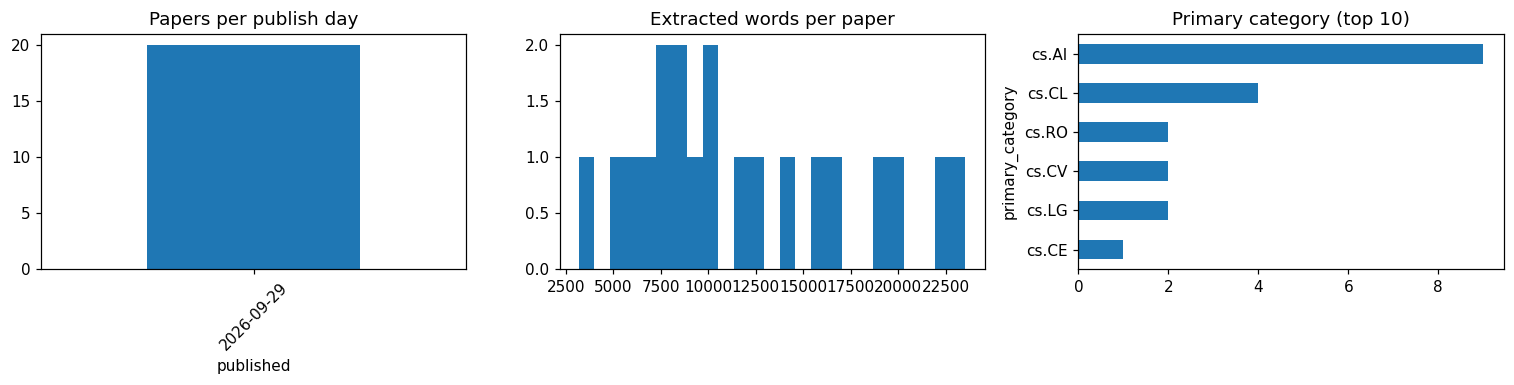

Most common categories including cross-lists:
 cs.AI              20
cs.LG              11
cs.CL               7
cs.CV               3
cs.RO               2
cs.IR               1
eess.SY             1
cs.CE               1
math.NA             1
physics.comp-ph     1


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
pub = pd.to_datetime(df["published"], utc=True)
text = df["extracted_text"].map(lambda v: v if isinstance(v, str) else "")
df["text_chars"] = text.str.len()
df["text_words"] = text.str.split().str.len()
df["abstract_words"] = df["abstract"].fillna("").str.split().str.len()
df["n_authors"] = df["authors"].map(lambda a: len(a) if isinstance(a, list) else 0)

print("Published:", pub.min(), "->", pub.max(), f"({(pub.max() - pub.min()).days} days)")
display(df[["text_chars", "text_words", "abstract_words", "n_authors"]].describe().round(0))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
pub.dt.strftime("%Y-%m-%d").value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Papers per publish day")
axes[0].tick_params(axis="x", rotation=45)
axes[1].hist(df["text_words"], bins=25); axes[1].set_title("Extracted words per paper")
df["primary_category"].value_counts().head(10).sort_values().plot(kind="barh", ax=axes[2], title="Primary category (top 10)")
plt.tight_layout(); plt.savefig(OUT / "basic_stats.png"); plt.show()

cross = pd.Series([c for cats in df["categories"] for c in cats]).value_counts().head(10)
print("Most common categories including cross-lists:\n", cross.to_string())

## 5. Extraction-quality audit

The status columns only say the extractor returned *something*. The signals below are **automated heuristics that nominate papers for manual review**; a signal is a reason to look, not proof of a problem.

| signal | why it matters |
|---|---|
| markdown escapes (`\%`, `\&`, `\_`) and HTML tags (`<sup>`) | leak into chunks and citations |
| `[Picture Omitted]` / leftover picture blocks | placeholder text or figure text inside chunks |
| repeated lines | running headers/footers or repeated table rows |
| table-like rows (`|`) | tables may lose alignment |
| math-symbol density | equation-heavy text may be flattened or garbled |
| replacement characters | encoding/extraction failure |
| abstract found in text | checks front matter and reading order |

In [7]:
ESC_RE = re.compile(r"\\[%&_$#]")
TAG_RE = re.compile(r"</?(?:sup|sub|br)\s*/?>", re.I)
PIC_RE = re.compile(r"\[Picture Omitted\]")
PICBLOCK_RE = re.compile(r"Start of picture text")
HYPH_RE = re.compile(r"\w-\n\w")
MATH_RE = re.compile(r"[=∑∫≤≥≈≠∈∉±×÷∂∇∞√αβγδεθλμπσφωΔΣΩ]")
REFS_RE = re.compile(r"^#{1,6}\s*\**\s*(?:\d+\.?\s*)?(references|bibliography)\b", re.I | re.M)
HEAD_RE = re.compile(r"^#{1,6}\s+\S", re.M)

def _norm(s):
    return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9 ]", " ", str(s).lower())).strip()

def signals_for(txt, abstract):
    n = len(txt)
    per10k = lambda k: k / n * 10_000 if n else np.nan
    lines = [l.strip() for l in txt.splitlines() if len(l.strip()) >= 12]
    counts = Counter(lines)
    repeated = sum(c for c in counts.values() if c >= 3)
    words = _norm(abstract).split()[:10]
    return {
        "text_chars": n,
        "headings": len(HEAD_RE.findall(txt)),
        "has_references": bool(REFS_RE.search(txt)),
        "abstract_found": bool(words) and " ".join(words) in _norm(txt),
        "escapes_per_10k": per10k(len(ESC_RE.findall(txt))),
        "html_tags": len(TAG_RE.findall(txt)),
        "picture_omitted": len(PIC_RE.findall(txt)),
        "picture_blocks_left": len(PICBLOCK_RE.findall(txt)),
        "replacement_chars": txt.count("\ufffd"),
        "hyphen_breaks": len(HYPH_RE.findall(txt)),
        "table_rows": sum(1 for l in txt.splitlines() if l.lstrip().startswith("|")),
        "math_per_10k": per10k(len(MATH_RE.findall(txt))),
        "repeated_line_frac": repeated / len(lines) if lines else 0.0,
    }

signals = pd.DataFrame([signals_for(t, a) for t, a in zip(text, df["abstract"].fillna(""))], index=df["arxiv_id"])
signals = signals[~signals.index.duplicated()]
display(signals.describe().round(2).T[["mean", "min", "50%", "max"]])

flag_summary = {
    "papers with markdown escapes": int((signals["escapes_per_10k"] > 0).sum()),
    "papers with HTML tags (<sup> etc.)": int((signals["html_tags"] > 0).sum()),
    "papers with [Picture Omitted]": int((signals["picture_omitted"] > 0).sum()),
    "papers with leftover picture blocks": int((signals["picture_blocks_left"] > 0).sum()),
    "papers with replacement characters": int((signals["replacement_chars"] > 0).sum()),
    "papers with table-like rows": int((signals["table_rows"] > 0).sum()),
    "papers with >10% repeated lines": int((signals["repeated_line_frac"] > 0.10).sum()),
    "papers where abstract not found in text": int((~signals["abstract_found"]).sum()),
    "papers with no References heading": int((~signals["has_references"]).sum()),
    "papers with no markdown headings": int((signals["headings"] == 0).sum()),
}
display(pd.Series(flag_summary, name="papers").to_frame())

,mean,min,50%,max
text_chars,86644.35,22508.00,76941.00,180639.00
headings,41.25,14.00,30.50,144.00
escapes_per_10k,0.00,0.00,0.00,0.00
html_tags,196.25,11.00,115.00,827.00
picture_omitted,7.45,2.00,6.00,22.00
picture_blocks_left,0.00,0.00,0.00,0.00
replacement_chars,9.35,0.00,0.50,137.00
hyphen_breaks,0.00,0.00,0.00,0.00
table_rows,129.45,13.00,87.50,512.00
math_per_10k,22.35,0.78,15.87,69.41


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,papers
papers with markdown escapes,0
papers with HTML tags (<sup> etc.),20
papers with [Picture Omitted],20
papers with leftover picture blocks,0
papers with replacement characters,10
papers with table-like rows,20
papers with >10% repeated lines,3
papers where abstract not found in text,0
papers with no References heading,0
papers with no markdown headings,0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 5b. What is still there after preprocessing?

If the team's preprocessing step has been run (`python -m src.preprocessing.cli`, which writes `data/papers_clean.parquet`), the same signals are computed on the cleaned `body_text`. Anything that drops to zero is already handled; anything that remains is a real remaining problem. (`body_text` deliberately omits references, so the references/abstract/heading signals only apply to the raw text.)

In [8]:
CLEAN_PATH = ROOT / "data" / "papers_clean.parquet"
residual = None
if CLEAN_PATH.exists():
    clean = pd.read_parquet(CLEAN_PATH)
    if "body_text" in clean.columns:
        bt = clean["body_text"].map(lambda v: v if isinstance(v, str) else "")
        sig_clean = pd.DataFrame([signals_for(t, "") for t in bt], index=clean["arxiv_id"])
        residual = {
            "markdown escapes": int((sig_clean["escapes_per_10k"] > 0).sum()),
            "HTML tags (<sup> etc.)": int((sig_clean["html_tags"] > 0).sum()),
            "[Picture Omitted]": int((sig_clean["picture_omitted"] > 0).sum()),
            "leftover picture blocks": int((sig_clean["picture_blocks_left"] > 0).sum()),
            "replacement characters": int((sig_clean["replacement_chars"] > 0).sum()),
            "table-like rows": int((sig_clean["table_rows"] > 0).sum()),
            ">10% repeated lines": int((sig_clean["repeated_line_frac"] > 0.10).sum()),
        }
        raw_counts = {
            "markdown escapes": flag_summary["papers with markdown escapes"],
            "HTML tags (<sup> etc.)": flag_summary["papers with HTML tags (<sup> etc.)"],
            "[Picture Omitted]": flag_summary["papers with [Picture Omitted]"],
            "leftover picture blocks": flag_summary["papers with leftover picture blocks"],
            "replacement characters": flag_summary["papers with replacement characters"],
            "table-like rows": flag_summary["papers with table-like rows"],
            ">10% repeated lines": flag_summary["papers with >10% repeated lines"],
        }
        print(f"Cleaned rows: {len(clean)} (raw rows: {len(df)})")
        display(pd.DataFrame({"raw text (papers)": raw_counts, "after preprocessing (papers)": residual}))
    else:
        print("papers_clean.parquet has no body_text column; skipping.")
else:
    print(f"{CLEAN_PATH} not found. Run `python -m src.preprocessing.cli` from the project root "
          "(needs the branch that contains src/preprocessing) to include this comparison.")

/content/KPMG-1J-ai-research-intelligence-agent-for-business-insight-translation/data/papers_clean.parquet not found. Run `python -m src.preprocessing.cli` from the project root (needs the branch that contains src/preprocessing) to include this comparison.


## 6. Manual review: compare extracted text with the PDF

**This is the part a script cannot do.** The cell below picks papers that stand out on the signals above (plus one random paper). For each one: open its PDF, compare the printed START / MIDDLE / END / table excerpts with the same places in the PDF, then record what you saw in the next cell.

In [9]:
N_REVIEW = 6
rng = np.random.default_rng(42)
picks = {}

def pick(series, ascending, why, min_gt=None):
    """Pick the top paper for a signal. If min_gt is given, the paper's value must exceed it
    (so a signal that is zero everywhere nominates nobody)."""
    for pid in series.sort_values(ascending=ascending).index:
        if min_gt is not None and series[pid] <= min_gt:
            return
        if pid not in picks and len(picks) < N_REVIEW:
            picks[pid] = why
            return

pick(signals["text_chars"], True, "shortest extracted text")
pick(signals["text_chars"], False, "longest extracted text")
pick(signals["table_rows"], False, "most table-like rows", min_gt=0)
pick(signals["math_per_10k"].fillna(0), False, "densest math symbols", min_gt=0)
pick(signals["replacement_chars"], False, "most replacement characters (encoding damage?)", min_gt=0)
pick(signals["escapes_per_10k"].fillna(0), False, "most markdown escapes", min_gt=0)
pick(signals["repeated_line_frac"], False, "most repeated lines (headers/footers?)", min_gt=0)
for pid in signals.index[~signals["abstract_found"]]:
    if pid not in picks and len(picks) < N_REVIEW:
        picks[pid] = "abstract not found in extracted text"
for pid in signals.index[~signals["has_references"]]:
    if pid not in picks and len(picks) < N_REVIEW:
        picks[pid] = "no References heading found"
rest = [p for p in signals.index if p not in picks]
while len(picks) < N_REVIEW and rest:
    pid = rest.pop(int(rng.integers(len(rest))))
    picks[pid] = "random paper"

review_ids = list(picks)
review = (df.drop_duplicates("arxiv_id").set_index("arxiv_id").loc[review_ids, ["title", "pdf_url"]]
            .assign(why_picked=pd.Series(picks)))
display(review)

,title,pdf_url,why_picked
arxiv_id,,,
2609.38043v1,UserProxyBench: Evaluating LLM User Simulators for Agent Benchmarks and Trai...,https://arxiv.org/pdf/2609.38043v1,shortest extracted text
2609.38108v1,Do LLM Agents Execute the Plans They Declare? From Planning-Mode Declaration...,https://arxiv.org/pdf/2609.38108v1,longest extracted text
2609.38093v1,Character Training for Risk-Averse Agents,https://arxiv.org/pdf/2609.38093v1,most table-like rows
2609.38107v1,"Correct Answers, Invalid Traces: What Verifiable Grade-School Math Reveals A...",https://arxiv.org/pdf/2609.38107v1,densest math symbols
2609.38147v1,Thinking Before Thinking: Scaling Agentic Inference Through Meta-Reasoning,https://arxiv.org/pdf/2609.38147v1,most replacement characters (encoding damage?)
2609.38109v1,How Local Mixing Encodes Relative Position in Global NoPE Attention,https://arxiv.org/pdf/2609.38109v1,most repeated lines (headers/footers?)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
def _show(label, s):
    print(f"\n--- {label} ---")
    print(s if s else "(nothing to show)")

def excerpt_table(t, width=700):
    m = re.search(r"^\s*\|.*\|\s*$", t, re.M)
    return t[max(0, m.start() - 100): m.start() + width] if m else None

def excerpt_math(t, width=700):
    best, best_i = 0, None
    for i in range(0, max(1, len(t) - width), width // 2):
        k = len(MATH_RE.findall(t[i:i + width]))
        if k > best:
            best, best_i = k, i
    return t[best_i: best_i + width] if best_i is not None else None

def review_packet(pid, chars=1200):
    row = df.loc[df["arxiv_id"] == pid].iloc[0]
    t = row["extracted_text"] if isinstance(row["extracted_text"], str) else ""
    print("=" * 100)
    print(pid, "|", row["title"])
    print("Why picked :", picks[pid])
    print("Open PDF   :", row["pdf_url"])
    print("Text length:", f"{len(t):,} characters")
    mid = len(t) // 2
    _show("START (compare with page 1: title, authors, abstract, reading order)", t[:chars])
    _show("MIDDLE (compare with the page at ~50% of the PDF)", t[mid: mid + chars])
    _show("END (compare with the last pages)", t[-800:])
    _show("FIRST TABLE-LIKE ROWS (compare with the table in the PDF)", excerpt_table(t))
    _show("MOST MATH-DENSE PASSAGE (compare with the equations in the PDF)", excerpt_math(t))

# Work through the papers one at a time: run this cell, review, record (next cell), then change to 1, 2, ...
REVIEW_INDEX = 0
print(f"Paper {REVIEW_INDEX + 1} of {len(review_ids)}")
review_packet(review_ids[REVIEW_INDEX])

Paper 1 of 6
2609.38043v1 | UserProxyBench: Evaluating LLM User Simulators for Agent Benchmarks and Training
Why picked : shortest extracted text
Open PDF   : https://arxiv.org/pdf/2609.38043v1
Text length: 22,508 characters

--- START (compare with page 1: title, authors, abstract, reading order) ---
# **UserProxyBench: Evaluating LLM User Simulators for Agent Benchmarks and Training** 

**Ashish Jain** 

```
ashish@sarvam.ai
```

**Armaan Sandhu** 

```
apsandhu@umass.edu
```

## **Abstract** 

Interactive agent benchmarks and multi-turn reinforcement learning increasingly place a second language model in the role of the user. This simulated user controls what information the agent receives and when, yet current benchmarks score only the agent and do not directly measure whether the user correctly executed its assigned role. We introduce UserProxyBench, an evaluation layer over the _τ_ - bench family, and the User Fidelity Score (UFS), which measures adherence to the benchmark’s priv

### Record what you observed

Use `record(...)` once per paper **after** comparing with the PDF. Allowed fields: `start_ok`, `middle_ok`, `end_ok`, `tables`, `equations`, `column_order`, `references_mixed_in`, `headers_footers`, `garbled_symbols`, `notes`. Use short factual values such as `"yes"`, `"no"`, `"n/a (no table)"`, or a sentence. Unreviewed cells stay `NOT REVIEWED`, and the findings cell counts them honestly.

In [11]:
REVIEWER = "Abdullah"
FIELDS = ["start_ok", "middle_ok", "end_ok", "tables", "equations", "column_order",
          "references_mixed_in", "headers_footers", "garbled_symbols", "notes"]
manual_log = pd.DataFrame("NOT REVIEWED", index=pd.Index(review_ids, name="arxiv_id"), columns=FIELDS)
manual_log["reviewer"] = ""
manual_log["reviewed_on"] = ""

def record(pid, **fields):
    if pid not in manual_log.index:
        raise KeyError(f"{pid} is not one of the review papers: {review_ids}")
    bad = set(fields) - set(FIELDS)
    if bad:
        raise KeyError(f"unknown field(s) {sorted(bad)}; allowed: {FIELDS}")
    for k, v in fields.items():
        manual_log.loc[pid, k] = str(v)
    manual_log.loc[pid, "reviewer"] = REVIEWER
    manual_log.loc[pid, "reviewed_on"] = dt.date.today().isoformat()

# EXAMPLE (replace with what YOU saw in the PDF, then remove the leading # to run):
# record(review_ids[0], start_ok="yes", middle_ok="yes", end_ok="yes",
#        tables="no table in sampled section", equations="symbols flattened but readable",
#        column_order="correct", references_mixed_in="no", headers_footers="repeated title line on every page",
#        garbled_symbols="none seen", notes="...")

display(manual_log)

,start_ok,middle_ok,end_ok,tables,equations,column_order,references_mixed_in,headers_footers,garbled_symbols,notes,reviewer,reviewed_on
arxiv_id,,,,,,,,,,,,
2609.38043v1,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,,
2609.38108v1,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,,
2609.38093v1,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,,
2609.38107v1,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,,
2609.38147v1,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,,
2609.38109v1,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,NOT REVIEWED,,


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 7. Findings (generated from the numbers above)

In [12]:
n = len(df)
reviewed_mask = (manual_log[FIELDS] != "NOT REVIEWED").any(axis=1)
n_reviewed = int(reviewed_mask.sum())

def nz(d):
    d = {k: v for k, v in d.items() if v}
    return "; ".join(f"{k}: {v}" for k, v in d.items()) or "none"

recs = []
fs = flag_summary
def _rec(raw_n, res_key, text_raw, text_res):
    """text_res may contain {n}, replaced by the number of papers still affected after preprocessing."""
    if raw_n == 0:
        return
    if residual is None:
        recs.append(text_raw)
    elif residual.get(res_key, 0) > 0:
        recs.append(text_res.replace("{n}", str(residual[res_key])))
    # residual == 0: preprocessing already handles it, so no recommendation

_rec(fs["papers with markdown escapes"], "markdown escapes",
     f"Unescape markdown escapes such as \\% and \\& before chunking ({fs['papers with markdown escapes']} of {n} raw papers).",
     "Markdown escapes such as \\% and \\& still remain after preprocessing in {n} papers; unescape body_text before chunking.")
_rec(fs["papers with HTML tags (<sup> etc.)"], "HTML tags (<sup> etc.)",
     f"Strip or convert HTML tags such as <sup> ({fs['papers with HTML tags (<sup> etc.)']} raw papers).",
     "HTML tags still remain after preprocessing in {n} papers.")
_rec(fs["papers with [Picture Omitted]"], "[Picture Omitted]",
     f"Decide whether [Picture Omitted] placeholders stay in chunks ({fs['papers with [Picture Omitted]']} raw papers, {int(signals['picture_omitted'].sum())} blocks).",
     "[Picture Omitted] placeholders still remain after preprocessing in {n} papers.")
_rec(fs["papers with leftover picture blocks"], "leftover picture blocks",
     f"Picture-text blocks survived cleaning in {fs['papers with leftover picture blocks']} raw papers; fix the cleaning pattern.",
     "Picture-text blocks still remain after preprocessing in {n} papers.")
_rec(fs["papers with >10% repeated lines"], ">10% repeated lines",
     f"Check running headers/footers/tables in {fs['papers with >10% repeated lines']} raw papers with many repeated lines.",
     "More than 10 percent of lines are still repeated after preprocessing in {n} papers; check for leftover headers or table rows.")
_rec(fs["papers with replacement characters"], "replacement characters",
     f"Replacement characters (encoding damage) in {fs['papers with replacement characters']} raw papers.",
     "Replacement characters still remain after preprocessing in {n} papers.")
if residual is not None and residual.get("table-like rows", 0) > 0:
    recs.append(f"Markdown tables remain in body_text of {residual['table-like rows']} papers; decide how the chunker treats them (splitting mid-table loses the column headers).")
if residual is not None and fs["papers with replacement characters"] > 0 and residual.get("replacement characters", 0) == 0:
    recs.append(f"Replacement characters were deleted (not repaired) by preprocessing in {fs['papers with replacement characters']} papers; spot-check that no meaningful symbol was lost (they can be footnote markers or line-wrap arrows).")
if fs["papers where abstract not found in text"]:
    recs.append(f"Abstract not found in the raw text of {fs['papers where abstract not found in text']} papers; check front matter/reading order (may be a LaTeX/format mismatch).")
if fs["papers with no References heading"]:
    recs.append(f"No References heading in {fs['papers with no References heading']} raw papers; reference stripping will miss them.")

findings = f"""# EDA findings (Abdullah)

Dataset source: team ingestion pipeline (`{RUN_INFO['dataset_path']}`, sha256 {RUN_INFO['dataset_sha256'][:12]}...)
Repository commit: {RUN_INFO['commit']}
Notebook run (UTC): {RUN_INFO['run_date_utc']}
Sample: {n} papers, published {RUN_INFO['published_min'][:16]} to {RUN_INFO['published_max'][:16]} UTC

## Automated checks
- Missing values (null, blank, empty list): {nz(missing['total'].to_dict())}
- Duplicates: {nz(dup_counts)}
- Status/text/file contradictions: {nz(contradictions)}
- Extracted length: median {int(df['text_words'].median()):,} words (min {int(df['text_words'].min()):,}, max {int(df['text_words'].max()):,})
- Extraction-quality signals (raw text): {nz(flag_summary)}
- After preprocessing (body_text, papers still affected): {nz(residual) if residual is not None else 'not checked (papers_clean.parquet not found)'}

## Manual review
Reviewed {n_reviewed} of {len(review_ids)} selected papers ({', '.join(review_ids)}).
""" + ("**NOT YET DONE. Do not report manual findings until the log in section 6 is filled in.**\n" if n_reviewed == 0 else
       "Observations are in `manual_review_log.csv` (summarize them here in your own words).\n") + f"""
## Recommended cleaning / pipeline fixes (from measured signals)
""" + ("\n".join(f"- {r}" for r in recs) or "- none triggered by the automated signals") + """

## Limitations
- Small recent-paper sample; not representative of all AI research.
- Word/character counts are approximate and include Markdown, tables and references.
- Signals are heuristics; only the manual review checks correctness against the PDFs.
"""
print(findings)

# EDA findings (Abdullah)

Dataset source: team ingestion pipeline (`data/papers.parquet`, sha256 842e8108e452...)
Repository commit: 5435927f9c3673bca32a0f464ef62bd7e7e3bd3e
Notebook run (UTC): 2026-09-30 05:06
Sample: 20 papers, published 2026-09-29 17:08 to 2026-09-29 17:59 UTC

## Automated checks
- Missing values (null, blank, empty list): none
- Duplicates: none
- Status/text/file contradictions: none
- Extracted length: median 10,340 words (min 3,192, max 23,531)
- Extraction-quality signals (raw text): papers with HTML tags (<sup> etc.): 20; papers with [Picture Omitted]: 20; papers with replacement characters: 10; papers with table-like rows: 20; papers with >10% repeated lines: 3
- After preprocessing (body_text, papers still affected): not checked (papers_clean.parquet not found)

## Manual review
Reviewed 0 of 6 selected papers (2609.38043v1, 2609.38108v1, 2609.38093v1, 2609.38107v1, 2609.38147v1, 2609.38109v1).
**NOT YET DONE. Do not report manual findings until the log in

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 8. Save outputs

In [13]:
signals.to_csv(OUT / "extraction_signals.csv")
review.to_csv(OUT / "manual_review_selection.csv")
manual_log.to_csv(OUT / "manual_review_log.csv")
(OUT / "eda_findings.md").write_text(findings, encoding="utf-8")
(OUT / "run_info.json").write_text(json.dumps(RUN_INFO, indent=2), encoding="utf-8")
print("Saved to", OUT)
for p in sorted(OUT.iterdir()):
    print(f"  {p.name}  ({p.stat().st_size / 1e3:.0f} KB)")

if IN_COLAB:
    from google.colab import files
    archive = shutil.make_archive("/content/KPMG1J_EDA_Abdullah_outputs", "zip", OUT)
    files.download(archive)

Saved to /content/KPMG-1J-ai-research-intelligence-agent-for-business-insight-translation/reports/eda_abdullah
  basic_stats.png  (38 KB)
  eda_findings.md  (2 KB)
  extraction_signals.csv  (2 KB)
  manual_review_log.csv  (1 KB)
  manual_review_selection.csv  (1 KB)
  run_info.json  (0 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes for reviewers
- Re-run top to bottom from a fresh runtime. Section 6 needs your own `record(...)` calls before the findings are complete.
- Do not commit the parquet file or PDFs unless the team agrees; they are large generated data.
- No API key is needed for anything in this notebook.